In [1]:
import chipwhisperer as cw
import os, time

# (Assuming scope and target are already connected)
#bitstream_path =  r'C:\Users\sbista\ChipWhisperer\chipwhisperer\firmware\fpgas\aes\vivado_\cw305_aes.runs\impl_100t\cw305_top.bit'
bitstream_path =  r'/home/sareeta/chipwhisperer/firmware/fpgas/aes/vivado_protected/cw305_aes.runs/impl_100t/cw305_top.bit'
assert os.path.isfile(bitstream_path), f"Bitstream not found: {bitstream_path}"

# 2) Connect to the capture board (CWLite)
scope = cw.scope()
scope.default_setup()

# 3) Connect and Program the FPGA
print("Programming CW305 FPGA with:", bitstream_path)
target = cw.target(scope, cw.targets.CW305, bsfile=bitstream_path, force=True)


(ChipWhisperer NAEUSB WARNING|File naeusb.py:826) Your firmware (0.53.0) is outdated - latest is 0.54.0 See https://chipwhisperer.readthedocs.io/en/latest/firmware.html for more information


scope.gain.mode                          changed from low                       to high                     
scope.gain.gain                          changed from 0                         to 30                       
scope.gain.db                            changed from 5.5                       to 24.8359375               
scope.adc.basic_mode                     changed from low                       to rising_edge              
scope.adc.samples                        changed from 24400                     to 5000                     
scope.adc.trig_count                     changed from 638349                    to 21110998                 
scope.clock.adc_src                      changed from clkgen_x1                 to clkgen_x4                
scope.clock.adc_freq                     changed from 0                         to 29538459                 
scope.clock.adc_rate                     changed from 0.0                       to 29538459.0               
scope.clock.clkgen_

(ChipWhisperer Target WARNING|File CW305.py:591) Using default Verilog defines (/home/sareeta/chipwhisperer/software/chipwhisperer/hardware/firmware/cw305/cw305_aes_defines.v); if this is not what you want, provide them via the defines_files argument


In [2]:
from Crypto.Cipher import AES

# Known NIST AES-128 test vector
KEY = bytes.fromhex("2b7e151628aed2a6abf7158809cf4f3c")
PT  = bytes.fromhex("5c692f9103b2302914d7e555e4dcee49")

# Expected ciphertext
EXP_CT = AES.new(KEY, AES.MODE_ECB).encrypt(PT)
print("Expected CT:", EXP_CT.hex())


Expected CT: 06f36a65e8a99ff8907b2e5e5ddd77de


In [3]:
# Write KEY
target.fpga_write(target.REG_CRYPT_KEY, KEY)

# Write PLAINTEXT
target.fpga_write(target.REG_CRYPT_TEXTIN, PT)

# Trigger encryption
target.fpga_write(target.REG_CRYPT_GO, b"\x01")

# Small delay (AES is fast but be safe)
time.sleep(0.01)

In [4]:
# Read ciphertext
ct = bytes(target.fpga_read(target.REG_CRYPT_CIPHEROUT, 16))
print("FPGA CT   :", ct.hex())
print("MATCH?    :", ct == EXP_CT)

FPGA CT   : 06f36a65e8a99ff8907b2e5e5ddd77de
MATCH?    : True


In [5]:
# Set target round to 10 (the final round)
target.fpga_write(0x0C, [8]) 

# Run AES
target.fpga_write(target.REG_CRYPT_GO, [0x01])
time.sleep(0.01)

# Read both
ct = target.fpga_read(target.REG_CRYPT_CIPHEROUT, 16)
snap = target.fpga_read(0x0E, 16)

print(f"Cipherout: {ct.hex().upper()}")
print(f"Snapshot : {snap.hex().upper()}")

Cipherout: 06F36A65E8A99FF8907B2E5E5DDD77DE
Snapshot : 00000000000000000000000000000000


In [6]:
for i in range(10):
    target.fpga_write(target.REG_CRYPT_TEXTIN, PT)
    target.fpga_write(target.REG_CRYPT_GO, b"\x01")
    time.sleep(0.002)
    ct = bytes(target.fpga_read(target.REG_CRYPT_CIPHEROUT, 16))
    print(i, ct.hex())

0 06f36a65e8a99ff8907b2e5e5ddd77de
1 06f36a65e8a99ff8907b2e5e5ddd77de
2 06f36a65e8a99ff8907b2e5e5ddd77de
3 06f36a65e8a99ff8907b2e5e5ddd77de
4 06f36a65e8a99ff8907b2e5e5ddd77de
5 06f36a65e8a99ff8907b2e5e5ddd77de
6 06f36a65e8a99ff8907b2e5e5ddd77de
7 06f36a65e8a99ff8907b2e5e5ddd77de
8 06f36a65e8a99ff8907b2e5e5ddd77de
9 06f36a65e8a99ff8907b2e5e5ddd77de


In [7]:
scope.arm()
target.fpga_write(target.REG_CRYPT_TEXTIN, b"\x00"*16)
target.fpga_write(target.REG_CRYPT_GO, b"\x01")

if scope.capture():
    print("❌ Trigger not seen")
else:
    print("✅ Trigger OK")

✅ Trigger OK


Trace length: 5000


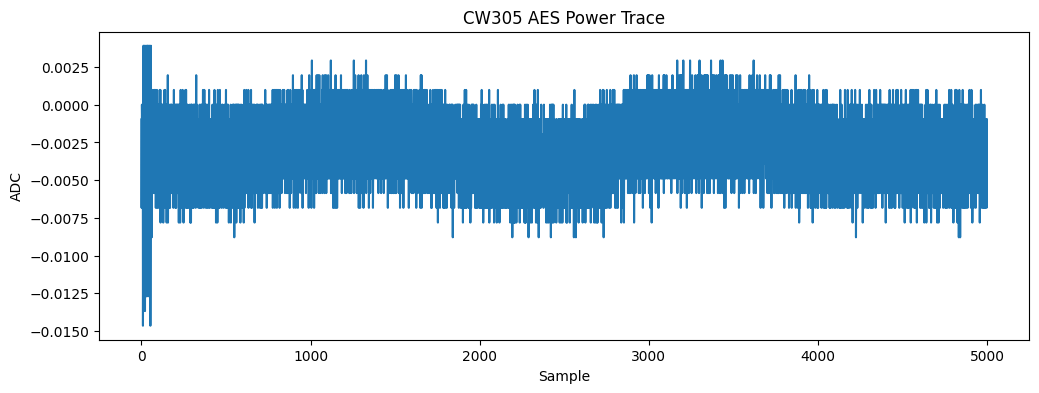

In [8]:

#KEY = bytes.fromhex("000102030405060708090a0b0c0d0e0f")
#PT  = bytes.fromhex("00112233445566778899aabbccddeeff")
#KEY = bytes.fromhex("2b7e151628aed2a6abf7158809cf4f3c")
#PT  = bytes.fromhex("5c692f9103b2302914d7e555e4dcee49")
# Load key once
target.fpga_write(target.REG_CRYPT_KEY, KEY)

# Arm scope
scope.arm()

# Launch AES
target.fpga_write(target.REG_CRYPT_TEXTIN, PT)
target.fpga_write(target.REG_CRYPT_GO, b"\x01")

# Capture
if scope.capture():
    raise RuntimeError("Timeout during capture")

# Read trace
trace = scope.get_last_trace()
print("Trace length:", len(trace))


import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.plot(trace)
plt.title("CW305 AES Power Trace")
plt.xlabel("Sample")
plt.ylabel("ADC")
plt.show()

In [9]:
import numpy as np
import time
N = 10000
traces = []
pts = []
cts = []

for i in range(N):
    pt = np.random.bytes(16)

    scope.arm()
    target.fpga_write(target.REG_CRYPT_TEXTIN, pt)
    target.fpga_write(target.REG_CRYPT_GO, b"\x01")

    if scope.capture():
        print("Timeout at", i)
        continue

    trace = scope.get_last_trace()
    ct = bytes(target.fpga_read(target.REG_CRYPT_CIPHEROUT, 16))

    traces.append(trace)
    pts.append(pt)
    cts.append(ct)

print("Captured:", len(traces), "traces")


Captured: 10000 traces


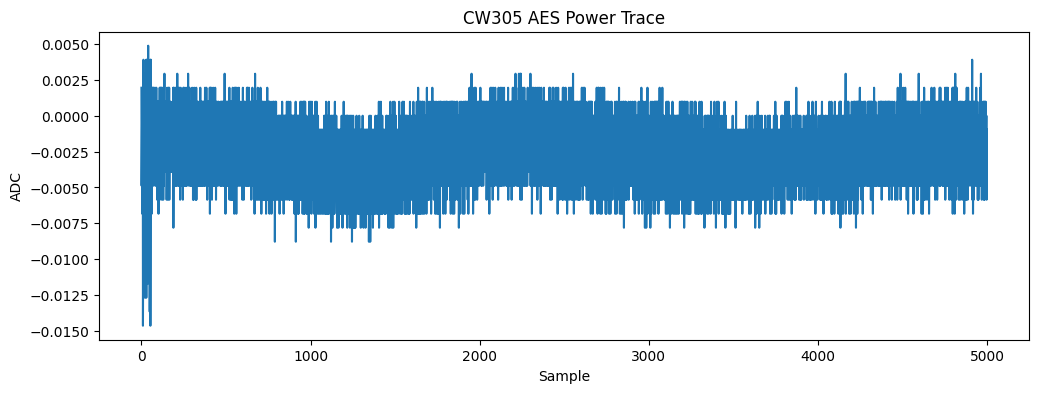

In [10]:
plt.figure(figsize=(12,4))
plt.plot(trace)
plt.title("CW305 AES Power Trace")
plt.xlabel("Sample")
plt.ylabel("ADC")
plt.show()

In [13]:
import numpy as np

# Convert lists to numpy arrays for efficient storage
traces_array = np.array(traces, dtype=np.float32)
pts_array = np.array([list(p) for p in pts], dtype=np.uint8)
cts_array = np.array([list(c) for c in cts], dtype=np.uint8)

# Save to a single compressed file
file_name = "normalaes_capture_10k.npz"
np.savez_compressed(file_name, 
                    traces=traces_array, 
                    pts=pts_array, 
                    cts=cts_array)

print(f"Successfully saved {len(traces)} traces to {file_name}")

Successfully saved 10000 traces to normalaes_capture_10k.npz


In [9]:
# scope.gain.gain = 46
# scope.gain.mode = "high"
# scope.adc.samples = 500
# scope.adc.offset = 0
# scope.adc.basic_mode = "rising_edge"
# scope.clock.adc_src = "clkgen_x4"
scope.clock.freq_ctr_src = "clkgen"
scope.clock.adc_phase = 0
scope.trigger.triggers = "tio4"

In [11]:
scope.io.hs2 = "glitch"
scope.glitch.clk_src = 'clkgen'
scope.glitch.ext_offset = 0

In [12]:
scope.glitch.trigger_src ="continuous" #"continuous" #change this depending on glitching desired   "ext_single"  "continuous"
scope.glitch.output = "clock_xor"

In [13]:
scope.glitch.width = 10
scope.glitch.offset = -20
#self.api.setParameter(['Glitch Module', 'Output Mode', 'Clock XORd'])
scope.glitch.repeat = 5   
print("Glitch ready.")

Glitch ready.


In [14]:
def aes_encrypt_once():
    # fire AES
    target.fpga_write(target.REG_CRYPT_TEXTIN, PT)
    target.fpga_write(target.REG_CRYPT_GO, b"\x01")
    # small wait so ciphertext register updates even if trigger missed
    time.sleep(0.001)
    return bytes(target.fpga_read(target.REG_CRYPT_CIPHEROUT, 16))

def glitch_and_read():
    # arm scope + glitch
    scope.arm()

    # launch AES (this generates the external trigger used by ext_single)
    target.fpga_write(target.REG_CRYPT_TEXTIN, PT)
    target.fpga_write(target.REG_CRYPT_GO, b"\x01")

    # capture waveform (optional but useful for debugging alignment)
    cap_timeout = scope.capture()
    ct = bytes(target.fpga_read(target.REG_CRYPT_CIPHEROUT, 16))

    if cap_timeout:
        return "no_trigger", ct, None

    tr = scope.get_last_trace()

    if ct == EXP_CT:
        return "correct", ct, tr
    else:
        return "faulty", ct, tr


for i in range(10):
    label, ct, tr = glitch_and_read()
    print(i, label, ct.hex())

0 correct 06f36a65e8a99ff8907b2e5e5ddd77de
1 correct 06f36a65e8a99ff8907b2e5e5ddd77de
2 correct 06f36a65e8a99ff8907b2e5e5ddd77de
3 correct 06f36a65e8a99ff8907b2e5e5ddd77de
4 correct 06f36a65e8a99ff8907b2e5e5ddd77de
5 correct 06f36a65e8a99ff8907b2e5e5ddd77de
6 correct 06f36a65e8a99ff8907b2e5e5ddd77de
7 correct 06f36a65e8a99ff8907b2e5e5ddd77de
8 correct 06f36a65e8a99ff8907b2e5e5ddd77de
9 correct 06f36a65e8a99ff8907b2e5e5ddd77de


In [15]:
import numpy as np

# Configuration
N_PER_SETTING = 5
records = []
traces = []
labels = []
faults = []
hits = {"correct": 0, "faulty": 0, "no_trigger": 0}

# Range Setup
widths  = range(-49, 49, 2)
offsets = range(-49, 49, 2)

print("Starting Glitch Loop...")

for w in widths:
    scope.glitch.width = w
    for off in offsets:
        scope.glitch.offset = off
        
        for rep in range(N_PER_SETTING):
            # --- THE WORKING LOGIC FROM CODE 1 ---
            scope.arm()
            
            # Launch AES
            target.fpga_write(target.REG_CRYPT_TEXTIN, PT)
            target.fpga_write(target.REG_CRYPT_GO, b"\x01")
            
            # Capture the hardware result
            cap_timeout = scope.capture()
            ct = bytes(target.fpga_read(target.REG_CRYPT_CIPHEROUT, 16))
            
            # Trace processing (from Code 2)
            tr = None
            if not cap_timeout:
                tr = np.array(scope.get_last_trace(), dtype=np.float32)
            # --------------------------------------

            # Labeling Logic
            if cap_timeout:
                label = "no_trigger"
            elif ct == EXP_CT:
                label = "correct"
            else:
                label = "faulty"
                faults.append((w, off, ct.hex()))
                print(f"FAULT! w={w} off={off} ct={ct.hex()}")

            # Store in Hits dictionary
            hits[label] += 1

            # Create the record (from Code 2)
            records.append({
                "width": w,
                "offset": off,
                "rep": rep,
                "label": label,
                "ct_hex": ct.hex(),
            })

            # Store trace if it exists
            if tr is not None:
                traces.append(tr)
                labels.append(label)

print("\n--- Scan Complete ---")
print("Summary:", hits)
print("Total records:", len(records))

Starting Glitch Loop...
FAULT! w=-41 off=1 ct=6afb362017f83b143426648602faa5e0
FAULT! w=-39 off=-29 ct=bca49a03f17c513107757a59c96adcf5
FAULT! w=-39 off=31 ct=34849e322d05343c69eee7a877ed66c1
FAULT! w=-37 off=1 ct=02155efe21756b7292f25a999224bf7f
FAULT! w=-35 off=1 ct=0600202520208008000104041011500e
FAULT! w=-33 off=-19 ct=f4a3497450e9d31eede7d3cc4fb8612f
FAULT! w=-29 off=27 ct=2b3aa656716cac95c023482816466b01


(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:1044) Trigger not found in ADC data. No data reported!
(ChipWhisperer Scope ERROR|File OpenADC.py:866) Received fewer points than expected: 0 vs 5000
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:1044) Trigger not found in ADC data. No data reported!
(ChipWhisperer Scope ERROR|File OpenADC.py:866) Received fewer points than expected: 0 vs 5000


FAULT! w=-23 off=25 ct=9007c4abf7399415365246f203c922bc


(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:1044) Trigger not found in ADC data. No data reported!
(ChipWhisperer Scope ERROR|File OpenADC.py:866) Received fewer points than expected: 0 vs 5000
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:730) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 0b
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:730) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 0a
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:730) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 0b
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:730) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 0a
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:730) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 0b
(ChipWhisperer Scope WARNING|File _OpenA

FAULT! w=-1 off=41 ct=7c054a3f90f3c08e180edac51841adac
FAULT! w=-1 off=41 ct=d51c4790691689771613cad769ed641e
FAULT! w=1 off=-27 ct=0782e861b7a359dcea77aa8811df55f8
FAULT! w=1 off=-27 ct=abf26acfc85e9789ca3a3c1b8e7d2f96


...

FAULT! w=39 off=-27 ct=06996a65e89c9ff8907b2e5e5ddd77de


(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:730) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 0b
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:730) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 0a
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:730) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 0b
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:730) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 0a


FAULT! w=43 off=7 ct=131f037d043ead9c801c707ddade5410


(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:730) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 0b
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:730) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 0a



--- Scan Complete ---
Summary: {'correct': 11908, 'faulty': 27, 'no_trigger': 70}
Total records: 12005



--- Sweeping ext_offset: w=1, off=-1 ---
  FAULT ext_off=465 byteflips=13 ΔC=06230a00000b0608002e060e0c0c260e
  FAULT ext_off=465 byteflips=13 ΔC=040208000c0806080008040e0004020e
  FAULT ext_off=470 byteflips=16 ΔC=4d2197094b8b8219f6a2e249bceb9271
  FAULT ext_off=470 byteflips=16 ΔC=1ba63f9bb8d0663a341704beee3ac834
  FAULT ext_off=470 byteflips=16 ΔC=e191c08ca56e61ff6747d8d28a29964a
  FAULT ext_off=470 byteflips=16 ΔC=3925aea069bb628432e36e9a93b9e74d
  FAULT ext_off=475 byteflips=16 ΔC=06f36a45eda99ff89679265e5dd577de
  FAULT ext_off=475 byteflips=16 ΔC=0edf6a61c28991d1b6580e7c57d45ffa
  FAULT ext_off=475 byteflips=16 ΔC=0930673b7a65fb47131bad32da36bcbf
  FAULT ext_off=475 byteflips=16 ΔC=8d1966f8daa54b0e1bb5a8d043f01bb7
  FAULT ext_off=475 byteflips=16 ΔC=7aed787c23e4790a53f49050721dcb44
  FAULT ext_off=480 byteflips=16 ΔC=021771960278b8317676b49b624175bc
  FAULT ext_off=480 byteflips=16 ΔC=d4e5c07ba20ac5feff24421f04710592
  FAULT ext_off=480 byteflips=16 ΔC=27da4bd40f468d4c72a26cd44

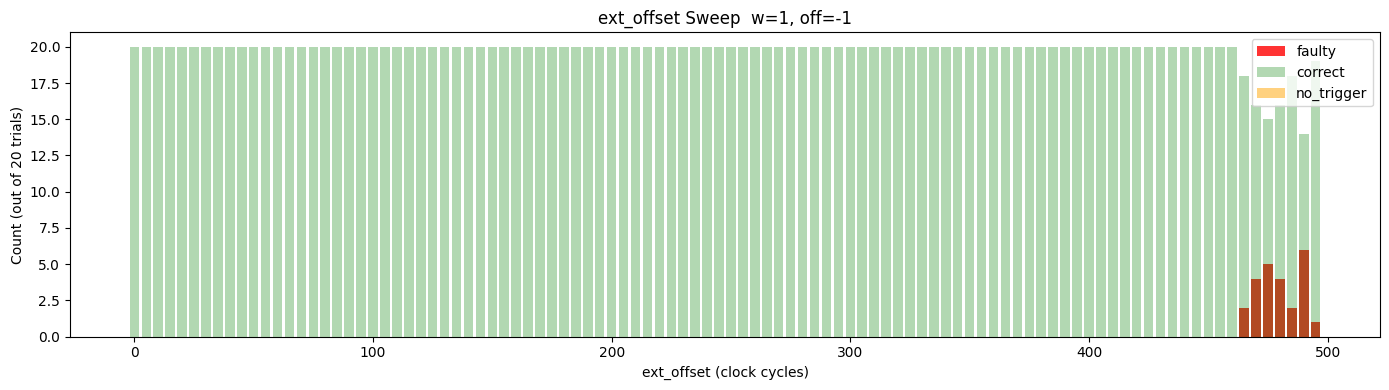

Total faults found: 24 / 2000 attempts

--- Sweeping ext_offset: w=33, off=17 ---


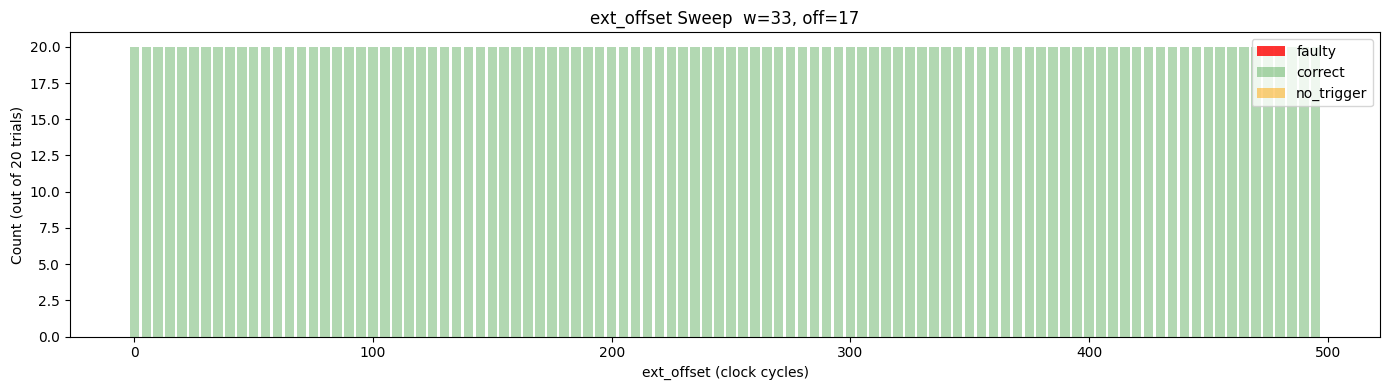

Total faults found: 0 / 2000 attempts


In [16]:
import numpy as np
from Crypto.Cipher import AES as _AES

EXP_CT = _AES.new(KEY, _AES.MODE_ECB).encrypt(PT)

# Use your TWO best parameter pairs
BEST_PARAMS = [
    {"width": 1,  "offset": -1},
    {"width": 33,  "offset": 17},
]

for params in BEST_PARAMS:
    w   = params["width"]
    off = params["offset"]

    scope.glitch.width       = w
    scope.glitch.offset      = off
    scope.glitch.repeat      = 5
    scope.glitch.trigger_src = "ext_single"
    scope.glitch.output      = "clock_xor"

    results_ext = []
    TRIALS = 20

    print(f"\n--- Sweeping ext_offset: w={w}, off={off} ---")

    for ext_off in range(0, 500, 5):
        scope.glitch.ext_offset = ext_off

        hits = {"correct": 0, "faulty": 0, "no_trigger": 0}

        for _ in range(TRIALS):
            scope.arm()
            target.fpga_write(target.REG_CRYPT_TEXTIN, PT)
            target.fpga_write(target.REG_CRYPT_GO, b"\x00")
            target.fpga_write(target.REG_CRYPT_GO, b"\x01")

            timed_out = scope.capture()
            ct = bytes(target.fpga_read(target.REG_CRYPT_CIPHEROUT, 16))

            if timed_out:
                label = "no_trigger"
            elif ct == EXP_CT:
                label = "correct"
            else:
                label = "faulty"
                delta    = bytes(a ^ b for a, b in zip(ct, EXP_CT))
                byteflips = sum(a != b for a, b in zip(ct, EXP_CT))
                print(f"  FAULT ext_off={ext_off} byteflips={byteflips} ΔC={delta.hex()}")

            hits[label] += 1

        results_ext.append({"ext_offset": ext_off, **hits})

    # Plot immediately after each param pair
    import matplotlib.pyplot as plt

    ext_offsets    = [r["ext_offset"] for r in results_ext]
    fault_counts   = [r["faulty"]     for r in results_ext]
    correct_counts = [r["correct"]    for r in results_ext]
    notrig_counts  = [r["no_trigger"] for r in results_ext]

    plt.figure(figsize=(14, 4))
    plt.bar(ext_offsets, fault_counts,   color="red",    alpha=0.8, label="faulty",     width=4)
    plt.bar(ext_offsets, correct_counts, color="green",  alpha=0.3, label="correct",    width=4)
    plt.bar(ext_offsets, notrig_counts,  color="orange", alpha=0.5, label="no_trigger", width=4)
    plt.xlabel("ext_offset (clock cycles)")
    plt.ylabel(f"Count (out of {TRIALS} trials)")
    plt.title(f"ext_offset Sweep  w={w}, off={off}")
    plt.legend()
    plt.tight_layout()
    plt.show()

    total_faults = sum(r["faulty"] for r in results_ext)
    print(f"Total faults found: {total_faults} / {500//5 * TRIALS} attempts")

In [17]:
scope.glitch.width      = 1
scope.glitch.offset     = -1
scope.glitch.repeat     = 5
scope.glitch.trigger_src = "ext_single"

print("Fine sweep around fault window edge...")

for ext_off in range(450, 470, 1):   # fine step=1
    scope.glitch.ext_offset = ext_off

    for _ in range(50):   # more trials at fine resolution
        scope.arm()
        target.fpga_write(target.REG_CRYPT_TEXTIN, PT)
        target.fpga_write(target.REG_CRYPT_GO, b"\x00")
        target.fpga_write(target.REG_CRYPT_GO, b"\x01")

        timed_out = scope.capture()
        ct = bytes(target.fpga_read(target.REG_CRYPT_CIPHEROUT, 16))

        if not timed_out and ct != EXP_CT:
            delta     = bytes(a ^ b for a, b in zip(ct, EXP_CT))
            byteflips = sum(1 for b in delta if b != 0)
            affected  = [i for i, b in enumerate(delta) if b != 0]
            print(f"ext_off={ext_off} byteflips={byteflips} bytes={affected} ΔC={delta.hex()}")

Fine sweep around fault window edge...
ext_off=453 byteflips=15 bytes=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 11, 12, 13, 14, 15] ΔC=64498af43e30bc6f2c3b00c26e4c8410
ext_off=453 byteflips=16 bytes=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15] ΔC=64f82fb1951c124861c05c7c89f016aa
ext_off=454 byteflips=16 bytes=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15] ΔC=2fab460be18e0982cae5061c21764cc6
ext_off=455 byteflips=16 bytes=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15] ΔC=6a8b6cada32a7c732a24e0bb85d7555a
ext_off=456 byteflips=16 bytes=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15] ΔC=80ebfb6e8010e7aeb50cbde9a1860aec
ext_off=457 byteflips=16 bytes=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15] ΔC=4f7f5d5495fd9eef8fc281e8784f4147
ext_off=458 byteflips=16 bytes=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15] ΔC=669c1521d9b1f60d3684c96312794219
ext_off=458 byteflips=16 bytes=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15] ΔC=a3f01e21bdbb9701ddb332

In [18]:
from Crypto.Cipher import AES as _AES
import numpy as np

EXP_CT = _AES.new(KEY, _AES.MODE_ECB).encrypt(PT)

# Strategy: very short repeat, fine-grained width/offset
# targeting shared logic before the cores diverge

scope.glitch.trigger_src = "ext_single"
scope.glitch.output      = "clock_xor"
scope.glitch.ext_offset  = 470   # your known fault window center

results = []

# Fine-grained sweep — much smaller steps than before
widths  = range(-10, 10, 1)   # narrow range, step=1
offsets = range(-10, 10, 1)   # narrow range, step=1
repeats = [1, 2, 3]           # keep repeat low — precise corruption

print("Hunting for symmetric fault...")

for repeat in repeats:
    scope.glitch.repeat = repeat
    for w in widths:
        scope.glitch.width = w
        for off in offsets:
            scope.glitch.offset = off

            for _ in range(20):
                scope.arm()
                target.fpga_write(target.REG_CRYPT_TEXTIN, PT)
                target.fpga_write(target.REG_CRYPT_GO, b"\x00")
                target.fpga_write(target.REG_CRYPT_GO, b"\x01")

                timed_out = scope.capture()
                ct = bytes(target.fpga_read(target.REG_CRYPT_CIPHEROUT, 16))

                if timed_out:
                    label = "no_trigger"
                elif ct == EXP_CT:
                    label = "correct"
                elif ct == bytes(16):
                    label = "caught_zero"
                else:
                    delta     = bytes(a ^ b for a, b in zip(ct, EXP_CT))
                    byteflips = sum(1 for b in delta if b != 0)
                    affected  = [i for i, b in enumerate(delta) if b != 0]

                    # THIS IS WHAT YOU WANT — low byteflips mean symmetric fault
                    if byteflips <= 8:
                        label = "symmetric_fault"
                        print(f"★ SYMMETRIC repeat={repeat} w={w} off={off} "
                              f"byteflips={byteflips} bytes={affected} "
                              f"ct={ct.hex()}")
                    else:
                        label = "random_fault"   # comparator triggered

                results.append({
                    "repeat": repeat, "width": w, "offset": off,
                    "label": label, "ct_hex": ct.hex()
                })

print("\nDone")
print("Symmetric faults found:", sum(1 for r in results if r["label"]=="symmetric_fault"))
print("Random faults (caught):", sum(1 for r in results if r["label"]=="random_fault"))

Hunting for symmetric fault...


(ChipWhisperer Glitch WARNING|File ChipWhispererGlitch.py:801) Partial reconfiguration for offset = 0 may not work
(ChipWhisperer Glitch WARNING|File ChipWhispererGlitch.py:801) Partial reconfiguration for offset = 0 may not work
(ChipWhisperer Glitch WARNING|File ChipWhispererGlitch.py:801) Partial reconfiguration for offset = 0 may not work
(ChipWhisperer Glitch WARNING|File ChipWhispererGlitch.py:801) Partial reconfiguration for offset = 0 may not work
(ChipWhisperer Glitch WARNING|File ChipWhispererGlitch.py:801) Partial reconfiguration for offset = 0 may not work
(ChipWhisperer Glitch WARNING|File ChipWhispererGlitch.py:801) Partial reconfiguration for offset = 0 may not work
(ChipWhisperer Glitch WARNING|File ChipWhispererGlitch.py:801) Partial reconfiguration for offset = 0 may not work
(ChipWhisperer Glitch WARNING|File ChipWhispererGlitch.py:801) Partial reconfiguration for offset = 0 may not work
(ChipWhisperer Glitch WARNING|File ChipWhispererGlitch.py:801) Partial reconfigu


Done
Symmetric faults found: 0
Random faults (caught): 22


In [19]:
# The comparator fires at the end of AES
# Try ext_offset values AFTER your current fault window

for ext_off in range(495, 600, 1):   # after your window
    scope.glitch.ext_offset = ext_off
    scope.glitch.width  = 1
    scope.glitch.offset = -1
    scope.glitch.repeat = 1   # very weak — just enough to flip comparator

    for _ in range(30):
        scope.arm()
        target.fpga_write(target.REG_CRYPT_TEXTIN, PT)
        target.fpga_write(target.REG_CRYPT_GO, b"\x00")
        target.fpga_write(target.REG_CRYPT_GO, b"\x01")

        timed_out = scope.capture()
        ct = bytes(target.fpga_read(target.REG_CRYPT_CIPHEROUT, 16))

        if not timed_out and ct != EXP_CT and ct != bytes(16):
            delta     = bytes(a ^ b for a, b in zip(ct, EXP_CT))
            byteflips = sum(1 for b in delta if b != 0)
            print(f"ext_off={ext_off} byteflips={byteflips} ct={ct.hex()}")

ext_off=495 byteflips=16 ct=ab22629005b0636b8a26699b9b6a2d20
ext_off=495 byteflips=16 ct=231ec49a2270900af7e5c0338ed3262c
ext_off=496 byteflips=15 ct=62ee04c46189b82a3fb42ee4d7912b7d
ext_off=496 byteflips=16 ct=2e16c074785f7a5af74fea391b06753b
ext_off=496 byteflips=16 ct=2d0fac2c437b177103d36cce7167a945
ext_off=497 byteflips=16 ct=c966392a5d8917b061b4e2203d2a03bc
ext_off=497 byteflips=16 ct=6621089943c1e7a62fdd6a4445efd339
ext_off=497 byteflips=16 ct=60af8acbb9c4e0f4448c37a8adb6f0f2
ext_off=497 byteflips=16 ct=ea1db9311dc03e910c53c7ce9ad12d6a
ext_off=497 byteflips=16 ct=c63062062567931ee027b5ebdbe6135a
ext_off=498 byteflips=16 ct=38445e91941ef1137bad284f7bb1febb
ext_off=498 byteflips=16 ct=1b03046ff6f0171304d4eb254245f03b
ext_off=498 byteflips=14 ct=06230a0528291f28102b2e0e1c0d270e
ext_off=498 byteflips=16 ct=dd71028e5290f8cc1a937eab8c3e7ff3
ext_off=499 byteflips=14 ct=06230a0408090e08002b2e0e0c0c260e
ext_off=500 byteflips=16 ct=f8a317bd5688be209c273c596114a3a9
ext_off=500 byteflips=16

In [ ]:
import numpy as np
import json

traces_np = np.vstack(traces)  # (num_captured, samples)

np.savez(
    "cw305_glitch_traces_3rd.npz",
    traces=traces_np,
    labels=np.array(labels, dtype="U10"),
    records_json=np.array([json.dumps(r) for r in records], dtype=object),
)

print("Saved: cw305_glitch_traces2nd.npz")
